## Guide to practical estimation of structure functions from data

### Why bother with SFs in the first place?

**Why structure functions in general?** They can be easily generalized across multiple orders, allowing for more detailed study of scaling behaviour, and in particular, the study of  intermittency via scale-dependent kurtosis.

**Why (de-biased) *second-order* structure functions in place of power spectra?**

- More robust to violations of stationarity
- Smoother
- Can handle gaps (up to a certain point)
- etc. 

### Dealing with uncertainty

*For theoretical details and Python implementation on both simulated and real-world solar wind data, see remainder of this notebook*

1. **Account for the random component of measurement/observation error** $\pm\sigma_{err}$ by subtracting the resultant bias: $S_2^{true}(\tau)=S_2^{obs}(\tau)-2\sigma^2_{err}$. (Failure to do so will result in a flattening at low frequencies and therefore slopes that are too shallow.) 
    
    Additionally, if the systematic component of the measurement error is non-constant (i.e. calibration drift), a de-trending or high-pass filter may be required to remove these artificial low frequencies from the data. That said, the SF has been shown to be relatively robust to this kind of noise *(Schulz-DuBois & Rehberg, 1981), (solar wind: APPENDIX B OF ROBERTS 2022, Appendix A of Chhiber2018 JGR) (Huang2014 disagrees?)*.
2. **Account for sampling error** by calculating a bootstrapped confidence interval for the derived statistic of interest (e.g., inertial range slope) using one of the following methods:
    - For the most complex yet statistically robust method, use the **wavelet (block) bootstrap** method described by [Wendt et al. (2007)](https://ieeexplore.ieee.org/document/4286563). Note that this method requires evenly-sampled data.
    - For a quicker method that can handle gaps, use **residual bootstrapping** of the fitted regression line. You will need to make sure that the residuals are reasonably uncorrelated. *cite*
    - For a somewhat more complex method that also gives the spread of the curves, not just the derived statistics, use **block bootstrapping** of the original time series. For turbulence applications (none in solar wind, that I found), see [Belange et al. (2023)](https://link.springer.com/article/10.1007/s00348-023-03704-w), [Theunissen et al. (2007)](https://link.springer.com/article/10.1007/s00348-007-0418-8), and [Garcia et al. (2005)](https://link.springer.com/article/10.1007/s00348-005-0091-8). Watch out for the block length (should be $\approx\lambda_C$) and points near block transitions.

*What happens when downsampling the time series? Binning lags? Something about the Freedman-Diaconis rule when choosing bin sizes...*

### Dealing with gaps

See elite work by D. Wrench

### Converting to an equivalent spectrum

See mid work by M. Bishop

### Choosing a suitable interval length

For this we must consider the following:

- Desired range of scales
- Stationarity and convergence of statistics: [Dudok de Wit et al. (2004)](https://journals.aps.org/pre/abstract/10.1103/PhysRevE.70.055302), [Kiyani et al. (2009)](https://scholar.google.com/scholar_url?url=https://journals.aps.org/pre/abstract/10.1103/PhysRevE.79.036109&hl=en&sa=T&oi=gsr-r&ct=res&cd=0&d=2750058327989828896&ei=5Ez_Z770FJGu6rQPyMPCuAs&scisig=AFWwaeb-9Mc5aBKqvPIk-kslCK3W), [Isaacs et al. (2015)](https://agupubs.onlinelibrary.wiley.com/doi/abs/10.1002/2014ja020661), [Jagarlamudi et al. (2019)](https://iopscience.iop.org/article/10.3847/1538-4357/aaef2e/meta)
- Influence of outliers: [Kiyani et al. (2006)](https://journals.aps.org/pre/abstract/10.1103/PhysRevE.74.051122) *TLDR: strong influence of outliers on scaling exponents can be reduced by removing the most extreme ones. Has been employed in SW studies, e.g. Roberts et al. (2020)*

---

# In-depth examination of uncertainty, with examples

In [17]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats, signal

from fbm import FBM

# Add .. to the path
import sys

sys.path.append("..")
import src.sf_funcs as sf_funcs

## Demo datasets

1. **Simulated data:** Fractional Brownian motion with a Hurst parameter of $H=1/3$, which gives our K41 scaling.

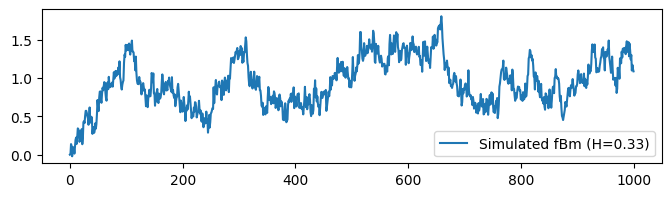

In [4]:
# Simulate fractional Brownian motion
np.random.seed(43)

n = 1000  # Number of points

hurst = 1 / 3  # Hurst parameter (0 < H < 1) = alpha/p for SF scaling
fbm_sim = FBM(n=n, hurst=hurst, length=1)
ts_sim = fbm_sim.fbm()

# Simulate AR(1) process
# phi = 0.9
# noise = np.random.normal(0, 1, n)
# ts_sim = np.zeros(n)
# for i in range(1, n):
#     ts_sim[i] = phi * ts_sim[i - 1] + noise[i]
plt.figure(figsize=(8, 2))
plt.plot(ts_sim, label=f"Simulated fBm (H={hurst:.2f})")
plt.legend()

2. **Real data:** Magnetic measurements of the LISM from Voyager 1. Uncertainties are as follows (from [Burlaga et al. 2018](https://iopscience.iop.org/article/10.3847/1538-4357/aaa45a/pdf)):

| Component | Full uncertainty (systematic + statistical) ( $\pm\sigma$ nT) | Statistical uncertainty ($\pm\sigma$ nT) |
| -------- | ------- |  ------- |
| $B_R$ | 0.06 | 0.005 |
| $B_T$ | 0.02 | 0.005 |
| $B_N$ | 0.02 | 0.005 |

In [5]:
data_full = pd.read_pickle("../data/interim/voyager/voyager1_lism_cleaned.pkl")
data_res = data_full.resample("48s").mean()
data_res.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7461001 entries, 2012-08-25 00:00:00 to 2023-12-31 00:00:00
Freq: 48s
Data columns (total 4 columns):
 #   Column  Dtype  
---  ------  -----  
 0   F1      float32
 1   BR      float32
 2   BT      float32
 3   BN      float32
dtypes: float32(4)
memory usage: 170.8 MB


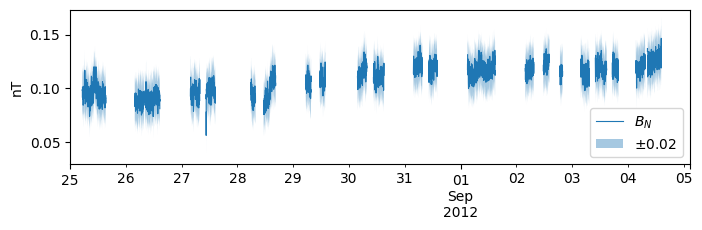

In [6]:
# Extract and plot the subset we'll study
v1_mag = data_res["BN"].iloc[:20000]
v1_err = 0.02

plt.figure(figsize=(8, 2))
v1_mag.plot(label="$B_N$", lw=0.8)

plt.fill_between(
    v1_mag.index,
    v1_mag - v1_err,
    v1_mag + v1_err,
    alpha=0.4,
    label=f"$\pm {v1_err}$",
)
plt.ylabel("nT")
plt.legend()

## Measurement error

Imprecision in the recording of data leads to measurement uncertainty. We can represent this error as a random variable $\mathbf{\epsilon}$ that is added to the 'true' value of our data $\mathbf{X}$, in order to get our observed values $\hat{\mathbf{X}}$:

$$\hat{\mathbf{X}}=\mathbf{X}+\mathbf{\epsilon}$$

This error $\epsilon$ can have two components: 

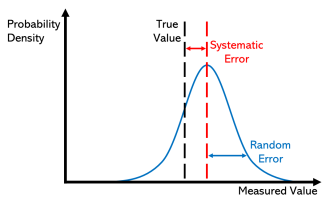 *From [Wikipedia](https://en.wikipedia.org/wiki/Observational_error)*
 
1. **systematic error**, which is generally a consistent offset to the true value (i.e., a *bias*). In this case of Voyager this results from issues around contamination by the spacecraft's magnetic field and telemetry errors, and comprises the majority of the error term. While it can generally be ignored since any bias is cancelled out when computing increments/fluctuations...

$$(X_1+b) - (X_2+b) = X_1 - X_2$$

...it can still warrant attention when is non-constant (i.e., subject to *drift*), as is the case with Voyager data. In this case it introduces low-frequency noise to the statistics, which requires something like a high-pass filter to remove.

2. **random error**. This is also referred to as *noise*, and in the case of magnetic field data usually results from instrument (thermal) noise and digitization errors. We always need to directly handle this error, and we will focus on this for the rest of this demonstration by assuming the $\epsilon$ is only a random error.

Random (measurement) error is typically assumed to be independent and identically distributed (i.i.d.) across all observations, and independent of the true signal. Additionally, it is modeled as normally distributed with zero mean and variance $\mathbf{\sigma}_{\mathbf{\epsilon}}^2$, giving the blue curve in the figure from Wikipedia above.

$$\mathbf{\epsilon}\sim N(0,\mathbf{\sigma}_{\mathbf{\epsilon}}^2)$$

We can get $\mathbf{\sigma}^2_\mathbf{\epsilon}$ by noting that typically data error bars in literature are expressed as $\mathbf{X}\pm\mathbf{\sigma}_\mathbf{\epsilon}$. (In some cases they may represent 95\% confidence intervals, in which case what is really expressed is $\mathbf{X}\pm1.96\mathbf{\sigma}_\mathbf{\epsilon}$.)

**This error does not affect the mean of our data**:

$$E[\hat{\mathbf{X}}]=E[\mathbf{X}+\mathbf{\epsilon}]=E[\mathbf{X}]+E[\mathbf{\epsilon}]=E[\mathbf{X}]$$

This follows from $E[A+B]=E[A]+E[B]$

**But it does inflate the variance**:

$$\text{Var}[\hat{\mathbf{X}}]=\text{Var}[\mathbf{X}+\mathbf{\epsilon}]=\text{Var}[\mathbf{X}]+\text{Var}[\mathbf{\epsilon}]+\text{Cov}[X,\mathbf{\epsilon}]=\text{Var}[\mathbf{X}]+\text{Var}[\mathbf{\epsilon}]=\text{Var}[\mathbf{X}]+\mathbf{\sigma}_{\mathbf{\epsilon}}^2$$

This follows from $\text{Var}(A+B)=\text{Var}(A)+\text{Var}(B)+\text{Cov}(A,B)$

**Seeing as the second-order structure function $\text{SF}$ is a measure of variance, it is also inflated by measurement error.** And since it is a function of two random variables $X_i, X_j$, with the same error distribution, we get two times the error variance as our upwards bias:

$$E[\hat{\text{SF}}(\tau)]=\text{SF}(\tau)+2\mathbf{\sigma}_{\mathbf{\epsilon}}^2$$

The full derivation of this is given in [Cucchetti et al. (2019)](https://www.aanda.org/articles/aa/pdf/2019/09/aa35677-19.pdf), Appendix A.3 and [ZuHone, Markevitch, and Zhuravleva (2019)](https://iopscience.iop.org/article/10.3847/0004-637X/817/2/110/pdf), Appendix C. (In those papers, they represent $\mathbf{\sigma}_{\mathbf{\epsilon}}^2$ as $\mathbf{\sigma}^2_{stat}$, to distinguish it from the systematic error variance $\mathbf{\sigma}^2_{sys}$.) They then show the downwards correction of this bias in their Figures 3 and 5, respectively:

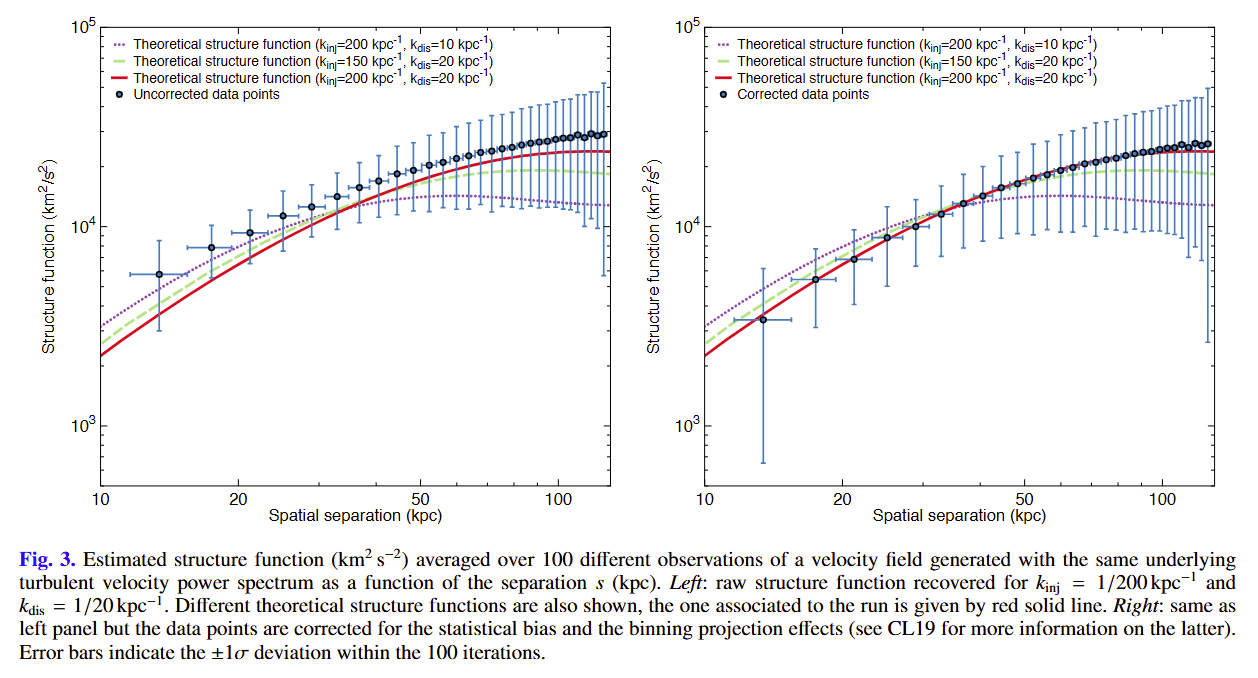

*^ From [Cucchetti et al. (2019)](https://www.aanda.org/articles/aa/pdf/2019/09/aa35677-19.pdf). In the right panel we can see that after subtracting the bias, the points lie much more in line with the red theoretical model.*

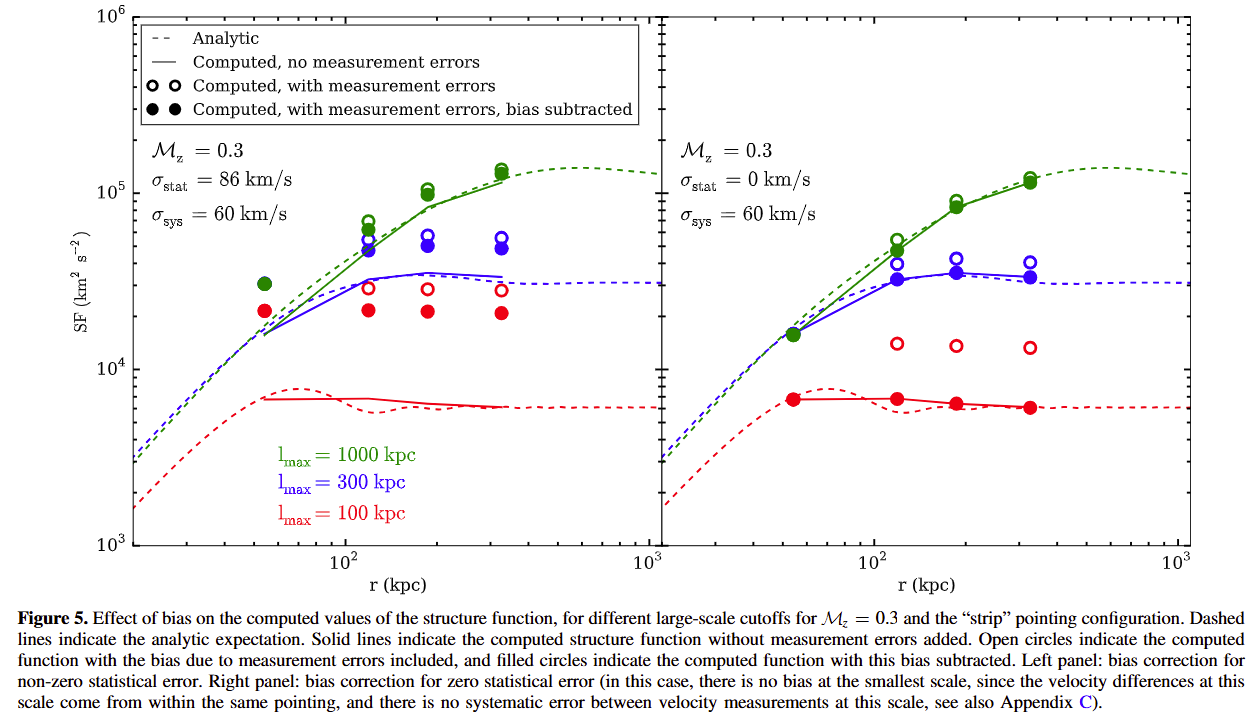

*^ From [ZuHone, Markevitch, and Zhuravleva (2019)](https://iopscience.iop.org/article/10.3847/0004-637X/817/2/110/pdf). Again, measurement errors cause upwards bias. Bias is strongest for the structure function with a small injection scale (red line). Their systematic error describes an error which is a constant offset within a given chunk of data (and therefore cancels out), but varies across chunks ('pointings'), and therefore needs modelling with a variance $\sigma_{sys}$. Given it does often cancel out, overall we see that statistical error is the dominant contributor to the bias.*

The former paper also derives the error that propagates into the four-term *variance* of the structure function, which we need for calculating confidence intervals:

$$\text{Var}[\hat{\text{SF}}(\tau)]=\text{Var}[\text{SF}(\tau)]+4\text{Var}[\text{D}(\tau)]\mathbf{\sigma}_{\mathbf{\epsilon}}^2+\frac{4}{N(\tau)}\text{SF}(\tau)\mathbf{\sigma}_{\mathbf{\epsilon}}^2+\frac{4(N_{nei}(\tau)+1)}{N(\tau)}\mathbf{\sigma}_{\mathbf{\epsilon}}^4$$

where $D(\tau)$ is the increment function (first-order SF), $N(\tau)$ is the number of lag pairs at lag $\tau$, and $N_{nei}(\tau)$ is the number of neighbours at a distance of $\tau$ at any given point.

If we have zero uncertainty in the data, this variance reduces to a single term: the 'intrinsic variance' of the structure function $\text{Var}[\text{SF}(\tau)]$. This is the uncertainty that results from sampling: **see next section**.

### Demo on simulated data
We can demonstrate the effect of measurement error by simulating it (given the error distribution), adding it to the time series, calculating the structure function, and doing this many times.

In [7]:
# Define function to "bootstrap" structure functions from time series with noise


def simulate_noise(x, max_lag, sigma_eps=None, snr=None, n_samples=1000, data_name="", plot_minus=False,  plot_noise_sf=False, log_axes=True):

    n = len(x)
    if sigma_eps is None:
        # Choose sigma such that the signal-to-noise ratio is snr
        sigma_eps = np.sqrt(np.var(x) / snr)
    if snr is None:
        # Calculate the signal-to-noise ratio
        snr = np.var(x) / sigma_eps**2

    # Remove any dated index (doesn't show up good in x-axis ticklabels)
    if type(x) == pd.Series:
        if type(x.index) == pd.DatetimeIndex:
            x.reset_index(drop=True, inplace=True)

    sf_true = sf_funcs.compute_sf(
        pd.DataFrame(x), np.arange(1, max_lag + 1), [2], False, False, None
    ).sf_2
    sf_noise = sf_funcs.compute_sf(
        pd.DataFrame(np.random.normal(0, sigma_eps, len(x))),
        np.arange(1, max_lag + 1),
        [2],
        False,
        False,
        None,
    ).sf_2

    sf_boot = np.zeros((n_samples, max_lag))

    x_boot_all = []

    for b in range(n_samples):

        x_boot = x + np.random.normal(0, sigma_eps, len(x))
        x_boot_all.append(x_boot)
        sf_boot[b] = sf_funcs.compute_sf(

            pd.DataFrame(x_boot), np.arange(1, max_lag + 1), [2], False, False, None


        ).sf_2

    # PLOT RESULTS
    fig, ax = plt.subplots(1, 2, figsize=(9, 4))
    for x_boot in x_boot_all:
        ax[0].plot(x_boot, c="grey", alpha=0.1)
    ax[0].plot(
        x_boot[0],
        label=f"X +$\epsilon, \epsilon \sim N(0,\sigma^2_{{\epsilon}})$ ({n_samples} samples)",
        color="grey",
    )
    ax[0].plot(x, label=f"X ({data_name})", color="blue")
    # Reorder the legend
    handles, labels = ax[0].get_legend_handles_labels()
    handles = [handles[1], handles[0]]
    labels = [labels[1], labels[0]]
    ax[0].legend(handles, labels, loc="upper left")

    ci_lower = np.percentile(sf_boot, 2.5, axis=0)
    ci_upper = np.percentile(sf_boot, 97.5, axis=0)

    # Plot
    lags = np.arange(1, max_lag + 1)

    ax[1].plot(lags, sf_true, label="SF(X)", color="blue")

    if plot_noise_sf:
        sf_noise = sf_funcs.compute_sf(
            pd.DataFrame(np.random.normal(0, sigma_eps, len(ts))),
            np.arange(1, max_lag + 1),
            [2],
            False,
            False,
            None,
        )

        ax[1].plot(
            lags, sf_noise.sf_2, label="SF($\epsilon_i$)", color="pink", alpha=0.8, lw=0.8
        )

    if plot_minus:
        sf_corr = sf_true - 2 * sigma_eps**2
        sf_corr_pos = sf_corr[sf_corr > 0]
        lags_corr_pos = lags[sf_corr > 0]
        ax[1].plot(
            lags_corr_pos,
            sf_corr_pos,
            label="SF(X) - 2$\sigma_{\epsilon}^2$",
            color="black",
            linestyle="--",
        )

        # Set ylimits
        # ax[1].set_ylim(sf_corr.min(), sf_true.max())
    else:
        for sf in sf_boot:
            ax[1].plot(lags, sf, color="grey", alpha=0.2)
        ax[1].plot(lags, sf_boot[0], color="grey", alpha=0.8, label="SF(X + $\epsilon_i$)")
        ax[1].plot(
            lags,
            sf_true + 2 * sigma_eps**2,
            label="SF(X) + 2$\sigma_{\epsilon}^2$",
            color="purple",
            linestyle="--",
        )
    # ax[1].plot(
    #     sf_true.lag[2:10],
    #     0.008 * np.power(sf_true.lag[2:10], 2 / 3),
    #     label="$\\tau^{2/3}$",
    #     color="black",
    #     linestyle=":",
    #     alpha=0.3,
    # )

    # ax[0].set_ylim(ts.min()-0.01, ts.max()+0.01)
    ax[0].set_title(
        f"Time series with added noise: ${{\sigma}}_{{\epsilon}}=${sigma_eps:.3f}, SNR={snr:.2f}"
    )
    ax[1].set_title(f"Corresponding structure functions")

    ax[1].set_xlabel("Lag (τ)")
    if log_axes:
        ax[1].set_xscale("log")
        ax[1].set_yscale("log")
    else:
        ax[1].axhline(2 * sigma_eps**2, color="gray", linestyle=":", label="2$\sigma_{\epsilon}^2$")
    # ax[1].set_ylim(0.01, 10)
    ax[1].legend(loc="lower right")
    # ax[1].set_ylim(5e-7,2e-4)
    fig.tight_layout()
    plt.show()

    return sf_true, sf_boot, sf_noise, x_boot_all, snr, sigma_eps

#### Comparing different amounts of measurement uncertainty

We can do this more intuitively by specifying the Signal-to-Noise Ratio (SNR), and then rearrange this to derive $\sigma_{\epsilon}$:

$$SNR=\frac{\text{Var}(\text{signal})}{\text{Var}\text{(noise)}}=\frac{\text{Var}(X)}{\sigma_{\epsilon}^2}$$

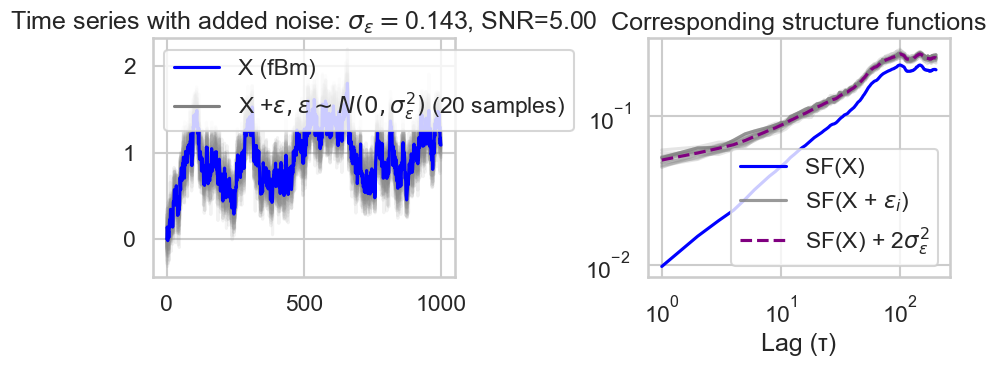

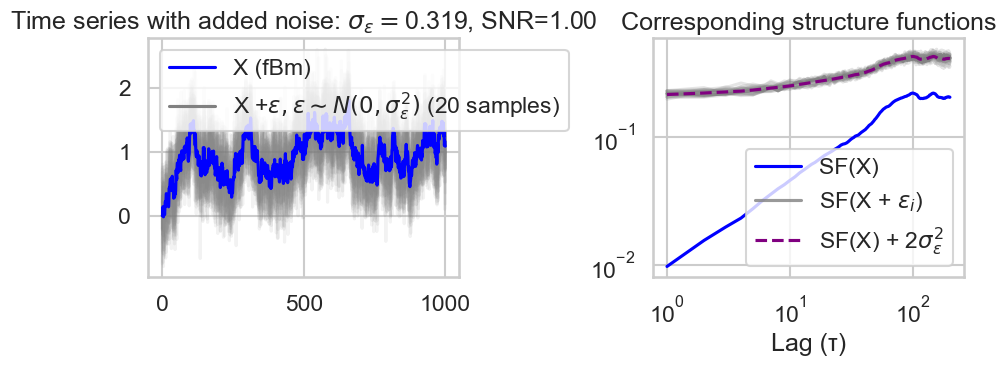

In [245]:
for snr in [5, 1]:
    sf_true, sf_boot, sf_noise, x_boot_all, snr, sigma_eps = simulate_noise(
        x=ts_sim, max_lag=200, snr=snr, n_samples=20, data_name="fBm"
    )

- The theoretical bias, given by the purple line in the right panel, matches very well with the results of our simulated noisy signals.
- Proportionally, measurement noise impacts small scales to a greater degree (small $\tau$) because that's where the signal differences are small. This scale-dependent effect results in a flattening of the curve in log-log space. **This will therefore lead to fitted slopes that are too small.**

### Demo on Voyager data

What we have with this real data is $\hat{\textbf{X}}$, not $\textbf{X}$, which means we should be *subtracting* $2\sigma_{\epsilon}^2$ from $\text{SF}$. We do this by changing an argument in the plotting function.

In [9]:
v1_err_stat = 0.005 # nT

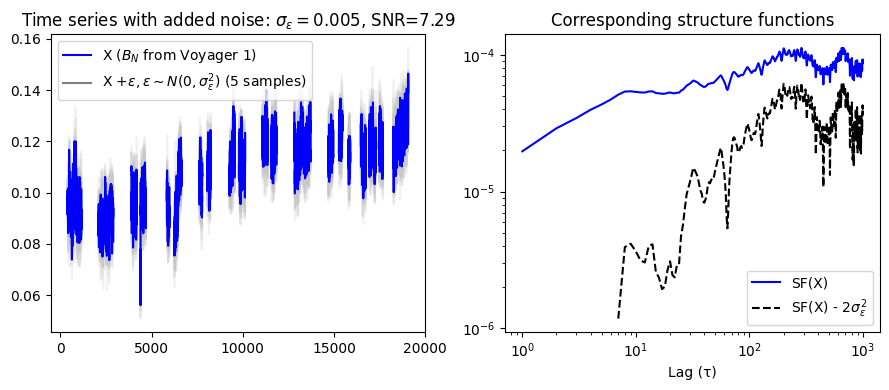

In [10]:
sf_true, sf_boot, sf_noise, x_boot_all, snr, sigma_eps = simulate_noise(
    x=v1_mag,
    max_lag=1000,
    sigma_eps=v1_err_stat,
    n_samples=5,
    data_name="$B_N$ from Voyager 1",
    plot_minus=True,
    log_axes=True
)

As expected, the corrected structure function is steeper. Note also we have had to disregard the first 6 lags where the corrected SF was smaller than zero.

What's particularly appealing about this correction is its relationship to the *nugget* effect from geostatistics, which describes the discontinuity of second-order SFs at the origin due to measurement noise. We can observe this for our data by switching to linear axes.

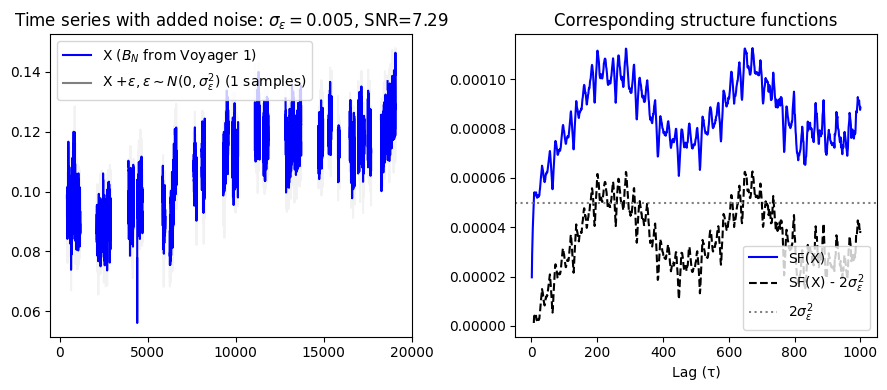

In [11]:
sf_true, sf_boot, sf_noise, x_boot_all, snr, sigma_eps = simulate_noise(
    x=v1_mag,
    max_lag=1000,
    sigma_eps=v1_err_stat,
    n_samples=1,
    data_name="$B_N$ from Voyager 1",
    plot_minus=True,
    log_axes=False,
)

As shown by the dotted horizontal line, this jump lines up extremely well with the reported measurement error.

*But what if we're averaging the data, or binning the SFs?*

## Sampling error

This is unavoidable error that occurs when statistics are estimated from a only a subset, or sample of the population. In the case of time series, this refers to the problem of estimating ensemble averages (e.g., structure functions, power spectra, and their derived statistics, e.g. slope, autocorrelation scale) from a finite dataset. It is reduced by having a larger sample size (or less variable population: if everything has the same value, the sampling error is always zero).

We want to model the uncertainty under repeated measurement scenarios, and therefore assess the robustness of estimated scaling behaviour: if we were to observe a slightly different interval, how much could the SF differ? We know that it could differ by a larger amount at large $\tau$ (fewer sample pairs contribute), and higher-order structure functions (sensitive to rare, extreme events.)

In the case of the sample mean, this is done with simple application of the central limit theorem:

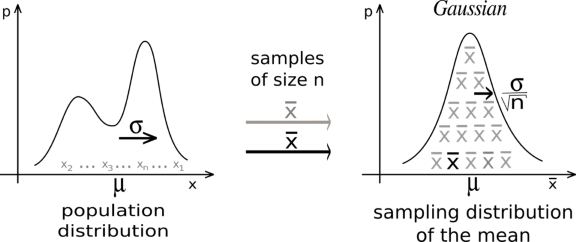 *From [Wikipedia](https://www.google.com/url?sa=i&url=https%3A%2F%2Fen.wikipedia.org%2Fwiki%2FCentral_limit_theorem&psig=AOvVaw2e_6Wx-rBfPtXMutDCfORo&ust=1746133492080000&source=images&cd=vfe&opi=89978449&ved=0CBcQjhxqFwoTCICzxarUgI0DFQAAAAAdAAAAABAE)*

We can use this formula to derive a 95% confidence interval for the sample mean, i.e. $\bar{x}\pm1.96\sigma/n$

Technically, the CLT only applies to the mean. For other statistics, it is better to use a **bootstrap procedure** in order to generate the distribution of our sampling stat.

Therefore, what we'd like is a way to derive the distribution of the sample statistic directly, without making these assumptions about the distribution of the data. Bootstrapping is a way to do this that involves re-sampling the original data, with replacement, in order to generate "plausible alternative realisations" of the data. (The only assumption here is that the sample/interval is representative of the population.)


### Direct estimation of slope distribution: residual bootstrapping


The bootstrap distribution of scaling exponents naturally incorporates both sampling variability and the uncertainty associated with fitting individual exponents. As each bootstrap resample undergoes an independent fitting procedure, the resulting confidence intervals reflect the combined effects of data variability and finite-size fitting noise, without requiring separate estimation of fitting uncertainty.

For spectra, people have bootstrapped the fits by residual resampling. You just fit your power-law, then add the residuals to the fit and re-fit. This perturbs the amplitudes around the best-fit model ([Carbone et al., 2020](https://www.mdpi.com/2218-1997/6/8/116), Telloni et al. 2021, Carbone et al. 2021):

This method is indeed commonly used in the literature for slopes, and kurtosis in particular

- Roberts et al. (2020, Frontiers in Physics) and (2022, JGRSP) performed 100 bootstrap resamplings of the fluctuations to derive errors bars for the kurtosis and structure functions.
- Duan et al. (2018) use bootstrapping to get error bars of the spectral break, by removing two random frequencies and re-fitting their power-laws.
- Carbone et al. (2020) used 600-1000 bootstrap resamples of the power spectrum and Hilbert spectrum to get error bars for the fitted slopes. I'm guessing by removing values from the spectra?



- \citet{bowen2024mediation} boostrapped 16 under-sampled distributions.
- Grošelj et al. (2019)

- Carbone et al. (2020, Universe)



In [260]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress

def plot_bootstrap_slopes(x, y, x_range=None, n_bootstrap=1000, random_seed=42):
    np.random.seed(random_seed)
    sns.set_theme(style="whitegrid", palette="colorblind", context="talk", font_scale=0.8)

    # Subset of data
    if x_range:
        mask = (x >= x_range[0]) & (x <= x_range[1])
        x_subset = x[mask]
        y_subset = y[mask]
    else:
        x_subset, y_subset = x, y

    slope_orig, intercept_orig, r_value, p_value, std_err = linregress(
        x_subset, y_subset
    )
    y_fit = intercept_orig + slope_orig * x_subset
    residuals = y_subset - y_fit

    # Bootstrap residuals
    slopes, intercepts = [], []
    for _ in range(n_bootstrap):
        resampled_resid = np.random.choice(residuals, size=len(residuals), replace=True)
        y_bootstrap = y_fit + resampled_resid
        s, i, *_ = linregress(x_subset, y_bootstrap)
        slopes.append(s)
        intercepts.append(i)

    slopes, intercepts = np.array(slopes), np.array(intercepts)

    y_boot_all = np.array(
        [intercepts[i] + slopes[i] * x_subset for i in range(n_bootstrap)]
    )
    ci_lower = np.percentile(y_boot_all, 2.5, axis=0)
    ci_upper = np.percentile(y_boot_all, 97.5, axis=0)
    slope_ci = np.percentile(slopes, [2.5, 97.5])

    fig, axes = plt.subplots(2, 2, figsize=(10, 6), constrained_layout=True)
    axes = axes.flatten()

    # Panel A: Initial fit
    axes[0].scatter(x, y, alpha=0.4, c="gray", s=2)
    axes[0].scatter(x_subset, y_subset, alpha=0.6, c="black", s=2)
    axes[0].plot(
        x_subset, y_fit, label=f"Original slope = {slope_orig:.3f}", color="C1", lw=3
    )
    axes[0].set_title("Initial fit")
    axes[0].set_xlabel("X")
    axes[0].set_ylabel("Y")
    axes[0].legend()
    axes[0].grid(True, alpha=0.5)

    # Panel B: Bootstrap CI and slope distribution
    axes[1].plot(x, y, alpha=0.4, c="gray", marker="o", markersize=2, lw=0.5)
    axes[1].plot(
        x_subset, y_subset, alpha=0.6, c="black", marker="o", markersize=2, lw=0.5
    )
    axes[1].plot(x_subset, y_fit, color="C1", lw=3)
    axes[1].fill_between(
        x_subset,
        ci_lower,
        ci_upper,
        alpha=0.3,
        color="C1",
        label=f"Slope = ({slope_ci[0]:.3f}, {slope_ci[1]:.3f})",
    )
    axes[1].set_title("Final Bootstrap 95% CI")
    axes[1].set_xlabel("X")
    axes[1].set_ylabel("Y")
    axes[1].legend()
    axes[1].grid(True, alpha=0.5)

    # Inset: Histogram of slopes
    ax_inset = axes[1].inset_axes([0.6, 0.1, 0.35, 0.35])
    sns.histplot(slopes, kde=False, ax=ax_inset, bins=30, color="grey")
    ax_inset.set_ylabel("")
    ax_inset.axvline(slope_orig, color="C1", linestyle="--", label="Subset slope")
    ax_inset.axvspan(slope_ci[0], slope_ci[1], color="C1", alpha=0.3, label="95% CI")
    ax_inset.set_title("Slope Distribution", fontsize=12)
    ax_inset.tick_params(axis="x", labelsize=10)
    ax_inset.tick_params(axis="y", which="both", left=False, labelleft=False)
    ax_inset.grid(False)

    # Panel C: Residuals vs. Fitted
    axes[2].scatter(y_fit, residuals, alpha=0.6, c="black")
    axes[2].axhline(0, color="C1")
    axes[2].set_title(r"$\it{Calculating\ Residuals}$")
    axes[2].set_xlabel("Fitted Values")
    axes[2].set_ylabel("Residuals")
    axes[2].grid(True, alpha=0.5)

    # Panel D: Bootstrap process (using stored slopes/intercepts)
    example_indices = np.random.choice(n_bootstrap, size=10, replace=False)
    colors = sns.color_palette("husl", 10)
    x_ordered = np.sort(x_subset)

    axes[3].plot(
        x_subset,
        y_subset,
        color="black",
        alpha=0.8,
        label="Original data",
        marker="o",
        markersize=3,
        lw=1,
    )
    for i, idx in enumerate(example_indices):
        slope_i = slopes[idx]
        intercept_i = intercepts[idx]
        y_boot_fit = intercept_i + slope_i * x_ordered

        # Simulated y_boot data (optional visual aid)
        y_boot = y_fit + np.random.choice(residuals, size=len(residuals), replace=True)
        axes[3].plot(
            x_subset,
            y_boot,
            color=colors[i],
            alpha=0.6,
            marker="o",
            markersize=2,
            lw=0.5,
        )
        axes[3].plot(x_ordered, y_boot_fit, color=colors[i], linewidth=2.5, alpha=0.8)

    axes[3].plot(x_subset, y_fit, linewidth=2, color="C1")
    axes[3].set_title(r"$\it{Adding\ Bootstrapped\ Residuals\ and\ Refitting}$")
    axes[3].set_xlabel("X")
    axes[3].set_ylabel("Y")
    axes[3].legend()
    axes[3].grid(True, alpha=0.5)

    # Add subplot labels
    labels = ["A", "D", "B", "C"]
    for ax, label in zip(axes, labels):
        ax.text(
            -0.1,
            1.1,
            label,
            transform=ax.transAxes,
            fontsize=16,
            fontweight="bold",
            va="top",
            ha="right",
        )

    # Print numerical results
    print(f"Original slope: {slope_orig:.6f}")
    print(f"95% CI for slope: [{slope_ci[0]:.6f}, {slope_ci[1]:.6f}]")
    print(f"R-squared: {r_value**2:.6f}")
    print(f"p-value: {p_value:.6f}")

    #plt.savefig("bootstrap_slopes.png", dpi=300, bbox_inches="tight")


#### Simulated data

Original slope: 0.663810
95% CI for slope: [0.654725, 0.673325]
R-squared: 0.997556
p-value: 0.000000


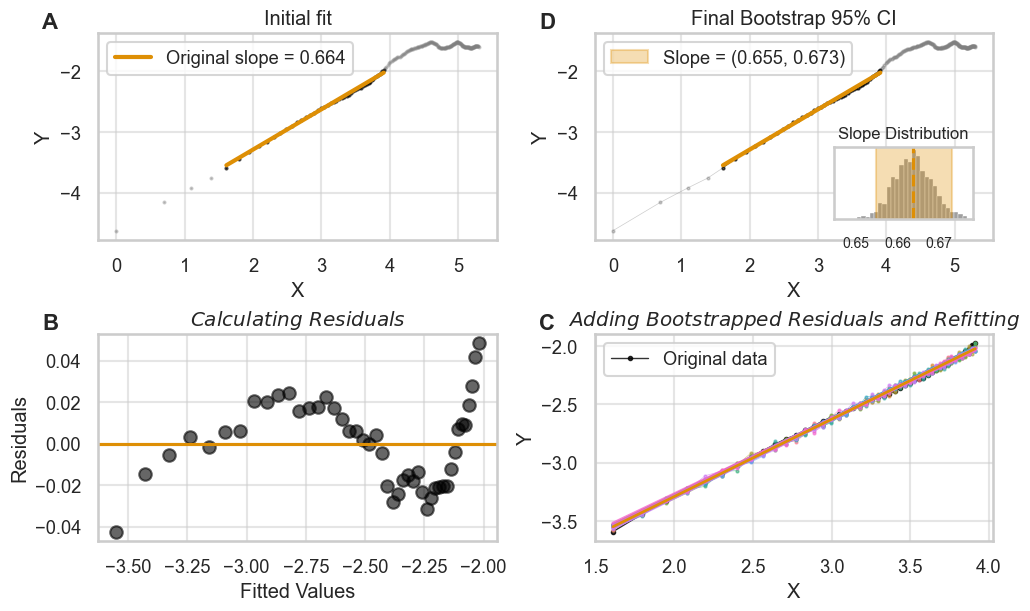

In [261]:
# Plot
ts = ts_sim
max_lag = 200

sf_true = sf_funcs.compute_sf(
    pd.DataFrame(ts), np.arange(1, max_lag + 1), [2], True, False, None
)

plot_bootstrap_slopes(np.log(sf_true.lag), np.log(sf_true.sf_2), x_range=(np.log(5),np.log(50)), n_bootstrap=1000)

#### Voyager data

In [263]:
sf_true = sf_funcs.compute_sf(
    pd.DataFrame(v1_mag), np.arange(1, 1000 + 1), [2], True, False, None
)

Original slope: 0.169042
95% CI for slope: [0.153049, 0.186269]
R-squared: 0.780910
p-value: 0.000000


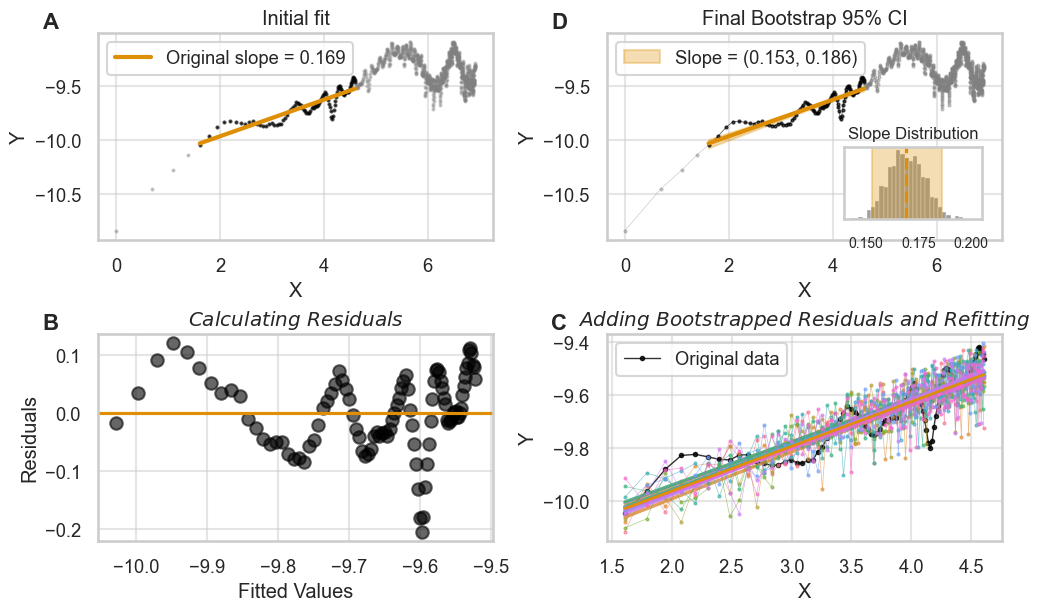

In [264]:
plot_bootstrap_slopes(np.log(sf_true.lag), np.log(sf_true.sf_2), x_range=(np.log(5), np.log(100)), n_bootstrap=1000)

### Estimation of SF distribution: lag-wise approach

But what if we don't just want the distribution of slopes, but the distribution over the entire curve?

What we want in the case of SFs is the distribution of the sample *variance*. In the ideal case of Gaussian data, [the sample variance follows a scaled chi-squared distribution](https://en.wikipedia.org/wiki/Variance#Population_variance_and_sample_variance). The standard error of the sample variance $S^2$ is then given by:

$$
\hat{\sigma}_{S^2} = S^2 \sqrt{\frac{2}{n - 1}}
$$

Applied to the structure function, this gives an approximate standard error:

$$
\sigma_{\text{SF}}(\tau) = \text{SF}(\tau) \sqrt{\frac{2}{N(\tau) - 1}}
$$

where $N(\tau)$ is the number of increment pairs at lag $\tau$. (As for what we specifically get when this variance is of the difference of two squared RVs: this has been derived by [Clec et al. (2019, Appendix F)](https://www.aanda.org/articles/aa/abs/2019/09/aa35676-19/aa35676-19.html) and [Ortiz & Deutsch (2002)](https://link.springer.com/article/10.1023/A:1014412218427).)


These analytical formulas can provide insight into how uncertainty scales with sample size
and lag. But there are issues at stake with these expressions. First is the assumption of
the shape of the distribution, which may only apply at large N.  For small $N(\tau)$ or heavy-tailed data, the SF distribution can deviate strongly from normality. 

In our case, we could generate "new" samples of squared increments at each lag, calculate the mean of each new sample, calculate the 2.5% and 97.5% percentiles, and use *this* as our estimate of the SF error **at each lag**. 

In [12]:
def get_lag_vals_list(df):
    lag_vals_wide = pd.DataFrame(df["diffs_2"].tolist(), index=df.index)
    lag_vals_wide.reset_index(inplace=True)  # Make the index a column
    lag_vals_wide.rename(columns={"index": "lag"}, inplace=True)
    lag_vals = pd.melt(
        lag_vals_wide, id_vars=["lag"], var_name="index", value_name="diffs_2"
    )
    return lag_vals

In [248]:
# Plot
ts = ts_sim
max_lag = 200

sf_true = sf_funcs.compute_sf(
    pd.DataFrame(ts), np.arange(1, max_lag + 1), [2], True, False, None
)

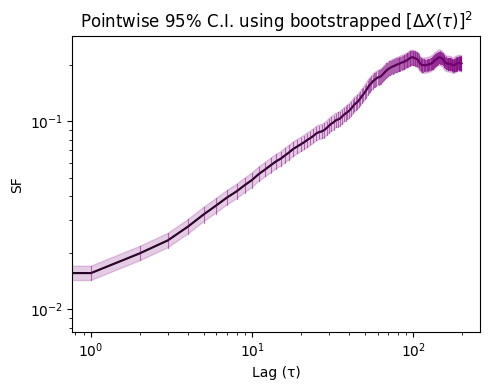

In [14]:
lags = np.arange(1, max_lag + 1)


# Calculate standard error assuming chi-squared approximation (pointwise error bars)

n_pairs = np.array([len(ts) - tau for tau in range(1, max_lag + 1)])
sf_se = sf_true.sf_2 * np.sqrt(2 / (n_pairs - 1))
ci_se_lower = sf_true.sf_2 - 1.96 * sf_se
ci_se_upper = sf_true.sf_2 + 1.96 * sf_se


# Plot with both bootstrap and pointwise SE intervals using fig, ax syntax

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(lags - 1, sf_true.sf_2, color="black")
lag_vals = get_lag_vals_list(sf_true)


# TAKES AGES FOR VOYAGER
sns.pointplot(
    x="lag",
    y="diffs_2",
    data=lag_vals,
    alpha=0.5,
    errorbar="ci",
    # n_boot=5,
    marker=None,
    c="purple",
    ax=ax,
    estimator="mean",
    lw=0.8,
)


ax.fill_between(
    lags - 1,
    ci_se_lower,
    ci_se_upper,
    color="purple",
    alpha=0.2,
)


ax.set_xlabel("Lag (τ)")
ax.set_ylabel("SF")
ax.set_title("Pointwise 95% C.I. using bootstrapped $[\Delta X(\\tau)]^2$")

ax.set_xscale("log")
ax.set_yscale("log")

fig.tight_layout()

plt.show()

The confidence interval based on the theoretical standard error of the sample variance, is approximately equal to the bootstrap confidence interval at a given lag (i.e., resampling with replacement the squared increments at that lag.) *This suggests that the raw differences are Gaussian enough, or the sample sizes large enough, for this convergence to occur.*

However, this **lag-wise bootstrapping** misses a vital fact about the data: data points, and therefore differences, are not independent. Pointwise confidence that we are currently expressing, either via analytical formulas or numerical simulation is inappropriate, and under-estimating the true uncertainty. In order to handle the serial correlation between lags, we need a method of calculating *joint* confidence intervals.

Therefore, bootstrapping of the underlying differences at each lag is inappropriate. We have three alternatives, keeping in mind that our principle aim is a *confidence interval for the fitted slope*.

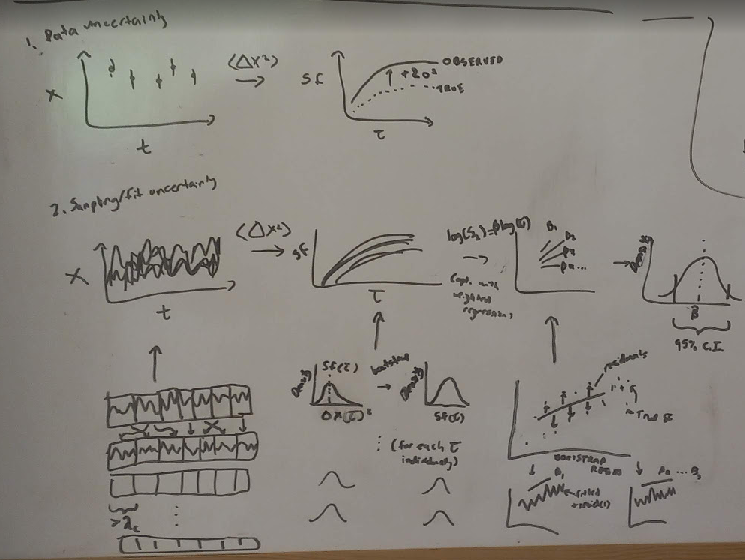


1. Generate an ensemble of SFs using 
    - **Bootstrap of the wavelet leaders of the data.** This is the most robust but most complicated method, and requires evenly-spaced data. 
    - **Bootstrap the original time series using block bootstrapping.** This requires careful setting of the block size in order to preserve sufficient autocorrelation properties.
2. Generate an ensemble of slopes from the original SF **bootstrapping the residuals of the power-law fit**. This is the most straightforward to implement, so we will start here.

### Block bootstrapping

One way that has been suggested for dealing with autocorrelation is *block bootstrapping*. Doing this in blocks preserves at least *some* of the correlation structure. However, it does not preserve long-run correlations, *and* it can lead to discontinuities at the boundaries between blocks.

Block bootstrapping perserves short-to-intermediate scale autocorrelations, depending on the blocksize.
We need to make sure 
- the block size is large enough to retain sufficient autocorrelation, i.e., **block size > max lag > $\lambda_C$**
- given this block size, the signal is long enough for many blocks.

### Simulated data

In [ ]:
def block_bootstrap_sf(x, max_lag, block_size, n_bootstraps=1000, random_state=None, plot=True, n_samples=3, data_name=""):

    def block_matches_with_na(block1, block2):
        """
        Check if two blocks match, accounting for NA values.
        Two blocks match if:
        1. Non-NA values in the same positions are close to each other
        2. NA patterns match (NA in block1 corresponds to NA in block2)
        """
        import numpy as np
        import pandas as pd

        # Convert to numpy arrays if they aren't already
        block1 = np.array(block1)
        block2 = np.array(block2)

        # Check if lengths match
        if len(block1) != len(block2):
            return False

        # Create masks for NA values
        mask1 = pd.isna(block1)
        mask2 = pd.isna(block2)

        # Check if NA patterns match
        if not np.array_equal(mask1, mask2):
            return False

        # For non-NA values, check if they are close
        non_na_indices = ~mask1  # Same as ~mask2 since we've verified they're equal

        # If all values are NA, blocks match
        if not np.any(non_na_indices):
            return True

        # Check if non-NA values are close
        return np.allclose(block1[non_na_indices], block2[non_na_indices], atol=1e-6)

    if random_state is not None:
        np.random.seed(random_state)


    n = len(x)
    n_blocks = n // block_size
    sf_boot = np.zeros((n_bootstraps, max_lag))
    x_boot_all = []

    for b in range(n_bootstraps):

        indices = np.random.randint(0, n_blocks, n_blocks)
        x_boot = np.concatenate(


            [x[i * block_size : (i + 1) * block_size] for i in indices]
        )


        x_boot_all.append(x_boot)
        sf_boot[b] = sf_funcs.compute_sf(
            pd.DataFrame(x_boot), np.arange(1, max_lag + 1), [2], False, False, None
        ).sf_2

    # return sf_boot, x_boot_all

    if plot:
        n = len(x)
        n_blocks = n // block_size

        fig, axes = plt.subplots(
            n_samples + 1, 1, figsize=(10, 1.5 * (n_samples + 1)), sharex=True
        )

        # --- x Time Series ---
        ax0 = axes[0]
        # Plot non-NA values and indicate NA values
        valid_mask = ~pd.isna(x)
        ax0.plot(np.arange(n), np.array(x), color="black")

        for i in range(n_blocks):
            start = i * block_size
            ax0.axvline(start, linestyle="--", alpha=0.5, color="black")

            ypos = np.nanmax(x) * 0.5
            if np.isnan(ypos):  # Handle case where all data might be NaN
                ypos = 0.5

            ax0.text(
                start + block_size / 2,
                ypos,
                f"{i}",
                ha="center",
                va="bottom",
                fontsize=10,
                fontweight="bold",
                bbox=dict(facecolor="white", edgecolor="black", boxstyle="round,pad=0.3"),
            )
        ax0.set_title(
            f"Original time series ({data_name}) with block indices", fontweight="bold"
        )
        ax0.axvline(n, linestyle="--", alpha=0.5, color="black")

        # --- Bootstrapped Samples ---
        for sample_idx in range(n_samples):
            sample = x_boot_all[sample_idx]
            ax = axes[sample_idx + 1]

            # Plot non-NA values in the bootstrap sample
            valid_mask_sample = ~pd.isna(sample)
            if np.any(valid_mask_sample):
                ax.plot(
                    np.arange(len(sample)),
                    np.array(sample),
                    color="black",
                    lw=0.5,
                )

            # Mark NA positions in bootstrap sample
            for i in range(0, len(sample), block_size):
                block = sample[i : i + block_size]

                # Identify origin block
                found_origin = -1
                for j in range(n_blocks):
                    orig_block = x[j * block_size : (j + 1) * block_size]
                    orig_block_size = min(block_size, len(orig_block))

                    # Compare blocks accounting for NAs
                    if block_matches_with_na(
                        block[:orig_block_size], orig_block[:orig_block_size]
                    ):
                        found_origin = j
                        break

                ax.axvline(i, linestyle="--", alpha=0.7, color="black")

                ypos = np.nanmax(sample) * 0.5
                if np.isnan(ypos):  # Handle case where all data might be NaN
                    ypos = 0.5

                ax.text(
                    i + block_size / 2,
                    ypos,
                    f"{found_origin}",
                    ha="center",
                    va="bottom",
                    fontsize=9,
                    bbox=dict(
                        facecolor="white", edgecolor="black", boxstyle="round,pad=0.3"
                    ),
                )

            # Add final vertical line for the last block
            ax.axvline(len(sample), linestyle="--", alpha=0.7, color="black")
            ax.set_title(f"Bootstrapped Sample ({sample_idx + 1})")

        plt.tight_layout()
        plt.show()

    return sf_boot, x_boot_all

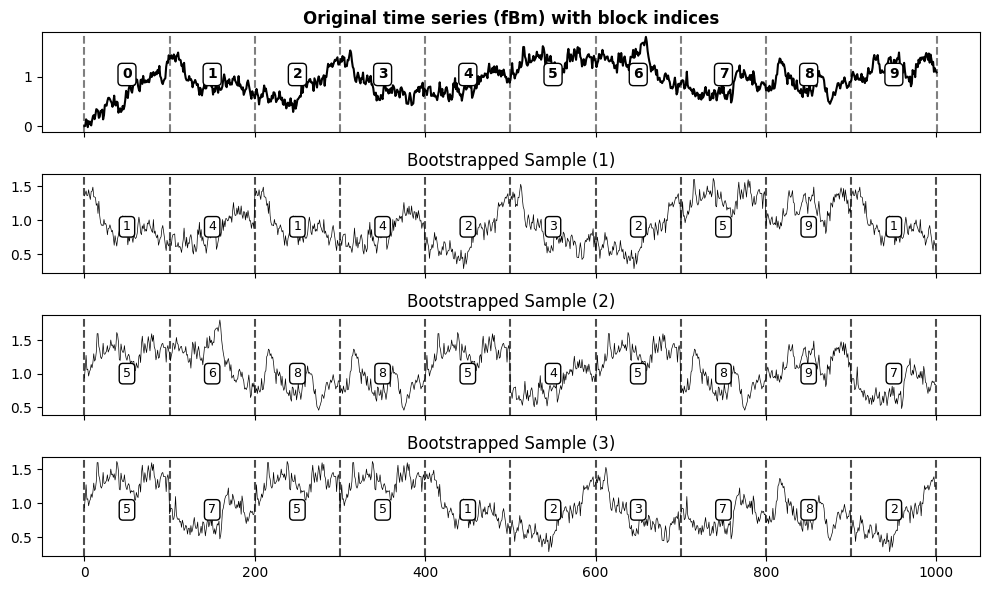

In [18]:
# Parameters
block_size = 100
n_bootstraps = 50
max_lag = 200

# Compute original SF and bootstrapped confidence intervals
ts = ts_sim

sf_true = sf_funcs.compute_sf(
    pd.DataFrame(ts), np.arange(1, max_lag + 1), [2], True, False, None
)
sf_boot, x_boot = block_bootstrap_sf(ts, max_lag, block_size, n_bootstraps, data_name="fBm")

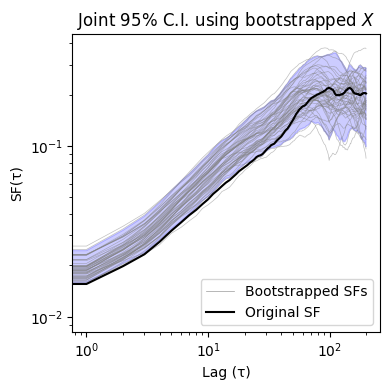

In [19]:
ci_lower = np.percentile(sf_boot, 2.5, axis=0)
ci_upper = np.percentile(sf_boot, 97.5, axis=0)

# Plot
lags = np.arange(1, max_lag + 1)

# Plot with both bootstrap and pointwise SE intervals using fig, ax syntax
fig, ax = plt.subplots(figsize=(4, 4))
for sf in sf_boot:
    ax.plot(lags-1, sf, color="grey", alpha=0.5, lw=0.5)
ax.plot(lags[0]-1, sf_boot[0][0], color="grey", alpha=0.8, lw = 0.5, label="Bootstrapped SFs")
ax.plot(lags-1, sf_true.sf_2, label="Original SF", color="black")


ax.set_xlabel("Lag (τ)")
ax.set_ylabel("SF(τ)")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Joint 95% C.I. using bootstrapped $X$")
ax.legend(loc="lower right")

ax.fill_between(lags - 1, ci_lower, ci_upper, color="blue", alpha=0.2)

fig.tight_layout()
plt.show()

Uh-oh. Block-bootstrapped fBm time series have seriously inflated SF values, especially at small lags, such that the CI doesn't even contain the true SF. This is likely from the introduction of artificial sharp discontinuities (**intermittency**) at block boundaries. At large lags, the SFs cluster around the true SF, as these are less affected, and the total signal variance at which the SF plateaus, is not biased by the bootstrapping procedure.

Overlapping blocks is less 'chunky' and preserves local dependencies somewhat better. But in general, block bootstrapping is going to be problematic due to how it affects the true intermittency of the signal.

Is there a different way? Yes. 

### Wavelet leader bootstrapping

A very relevant method has been developed which resamples not the increments, nor blocks of the time series, but the *wavelet leaders* of the time series. From these, the SFs and their corresponding slopes are estimated. It is described in depth, with turbulence analysis in mind, by 

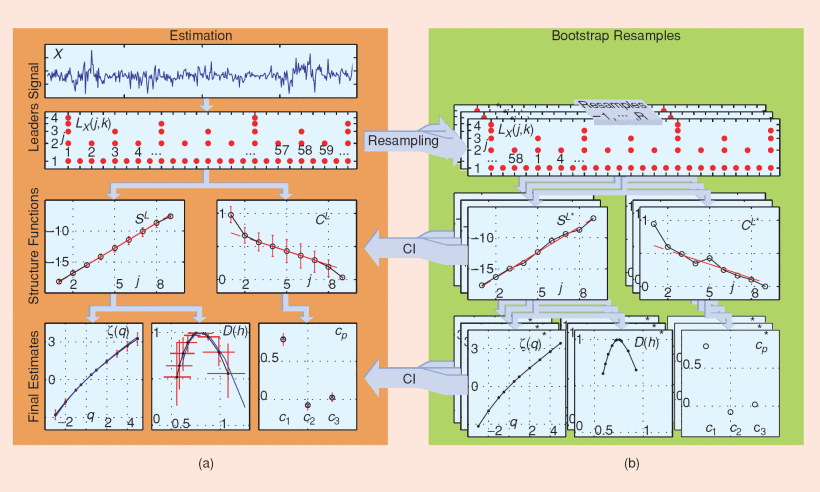

In [20]:
# MANUAL POINTWISE BOOTSTRAP OF SQUARED DIFFERENCES
# (this is already achieved by seaborn's sns.pointplot() above)

# # Initialize a dictionary to store the mean squared differences for each lag

# bootstrap_means = {}

# # Perform bootstrapping for 10 resamples
# n_resamples = 100
# for lag in lag_vals["lag"].unique():
#     bootstrap_means[lag] = []
#     for _ in range(n_resamples):
#         sq_diffs = lag_vals[lag_vals['lag'] == lag]["diffs_2"]
#         sq_diffs_resampled = sq_diffs.sample(frac=1.0, replace=True, random_state=None)
#         mean_sq_diff = np.mean(sq_diffs_resampled)
#         bootstrap_means[lag].append(mean_sq_diff)

# # Convert the results to a DataFrame for easier analysis
# bootstrap_means_df = pd.DataFrame(bootstrap_means)

# # Switch rows and columns
# bootstrap_means_df = bootstrap_means_df.transpose()

### Simulated data

### Voyager data

# Bonus
Daily averages of V1 LISM are very K41 monofractal! Certainly suggests not yet at outer scale...

In [21]:
data_res = data_full.resample("1d").mean()
data_res.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4146 entries, 2012-08-25 to 2023-12-31
Freq: D
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   F1      3969 non-null   float32
 1   BR      3969 non-null   float32
 2   BT      3969 non-null   float32
 3   BN      3969 non-null   float32
dtypes: float32(4)
memory usage: 97.2 KB


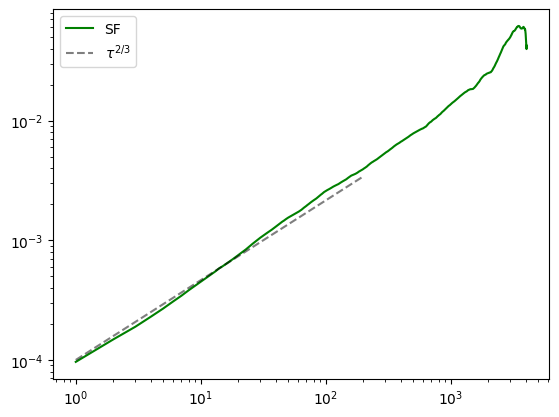

In [22]:
max_lag = 2000

sf_v1 = sf_funcs.compute_sf(
    data_res[["BR", "BT", "BN"]], np.arange(1, len(data_res)), [2], False, False, None
)

plt.plot(
    sf_v1.lag,
    sf_v1.sf_2,
    label="SF",
    color="green",
)

# Plot 2/3 power law
plt.plot(
    sf_true.lag,
    0.0001 * np.power(sf_true.lag, 2 / 3),
    label="$\\tau^{2/3}$",
    color="black",
    linestyle="--",
    alpha=0.5,
)
plt.legend()
plt.xscale("log")
plt.yscale("log")

Potentially relevant? 

- [Statistical inference of random field auto-correlation structure from multiple sets of incomplete and sparse measurements using Bayesian compressive sampling-based bootstrapping](https://www.sciencedirect.com/science/article/pii/S0888327019300652#s0065)
- [Interpolation uncertainty of atmospheric temperature profiles](https://amt.copernicus.org/articles/13/6445/2020/amt-13-6445-2020.html)